# Preprocesado y cacheo de datos para acelerar entrenamiento

**Motivo de este script:** Durante el proceso de entrenamiento del proyecto, observamos que cada epoch tardaba entre 30 y 60 minutos en completarse. Tras analizar el comportamiento del pipeline, detectamos que el principal cuello de botella se encontraba en la carga de imágenes por lotes (batches) y la aplicación de transformaciones en tiempo real. En algunos casos, este proceso llegaba a tardar más de 3 minutos por batch, lo que multiplicaba considerablemente el tiempo total por época.

Para solucionar este problema, decidimos implementar una estrategia de precacheo de datos. Esto consiste en aplicar las transformaciones necesarias una sola vez y guardar tanto las imágenes como las máscaras ya procesadas en disco. De esta forma, en los scripts de entrenamiento únicamente es necesario cargar estos datos cacheados, crear el DataLoader y proceder directamente al entrenamiento, reduciendo así de forma drástica el tiempo por epoch.

In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

import cv2
import matplotlib.pyplot as plt

In [3]:
# Carga del metadata
df = pd.read_csv("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/metadata.csv")
base_path = "/content/drive/MyDrive/Master_DL/DLVision/Practica/data"

In [4]:
# Dividir el dataframe en subsets: train, valid, test
train_df = df[df["split"] == "train"].dropna()
valid_df = df[df["split"] == "valid"]
test_df = df[df["split"] == "test"]

In [12]:
train_df.head()

,image_id,split,sat_image_path,mask_path
0,100034,train,train/100034_sat.jpg,train/100034_mask.png
1,100081,train,train/100081_sat.jpg,train/100081_mask.png
2,100129,train,train/100129_sat.jpg,train/100129_mask.png
3,100703,train,train/100703_sat.jpg,train/100703_mask.png
4,100712,train,train/100712_sat.jpg,train/100712_mask.png


Como podemos observar los datos de test y validación no incluyen máscaras solo las imágenes

In [13]:
valid_df.head()

,image_id,split,sat_image_path,mask_path
6226,100794,valid,valid/100794_sat.jpg,NaN
6227,100905,valid,valid/100905_sat.jpg,NaN
6228,102867,valid,valid/102867_sat.jpg,NaN
6229,10417,valid,valid/10417_sat.jpg,NaN
6230,106553,valid,valid/106553_sat.jpg,NaN


In [14]:
test_df.head()

,image_id,split,sat_image_path,mask_path
7469,100393,test,test/100393_sat.jpg,NaN
7470,100995,test,test/100995_sat.jpg,NaN
7471,101982,test,test/101982_sat.jpg,NaN
7472,10206,test,test/10206_sat.jpg,NaN
7473,102240,test,test/102240_sat.jpg,NaN


Se crea el dataset

In [5]:
class CachedRoadDataset(Dataset):
    def __init__(self, tensor_path, type = 'train'):
        self.type = type
        if self.type == 'train':
          self.images, self.masks = torch.load(tensor_path)
        elif self.type == 'valid':
          self.images = torch.load(tensor_path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.masks[idx]


Para el conjunto de datos de train, ya que incluye imágenes y máscaras

In [6]:
def build_and_cache_dataset(df, base_path, transform=None, save_path="/content/drive/MyDrive/Master_DL/DLVision/Practica/data"):
    images = []
    masks = []

    print("🧠 Precacheando dataset...")
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(base_path, row['sat_image_path'])
        mask_path = os.path.join(base_path, row['mask_path'])

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if image is None or mask is None:
            print(f"⚠️ Error con: {img_path}")
            continue

        if transform:
            augmented = transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        images.append(image)
        masks.append(mask)

    images = torch.stack(images)
    masks = torch.stack(masks)

    torch.save((images, masks), save_path)
    print(f"✅ Dataset guardado en {save_path}")

Para datos de valid y test, ya que solo incluye imágenes

In [7]:
def build_and_cache_validation_dataset(df, base_path, save_path = "/content/drive/MyDrive/Master_DL/DLVision/Practica/data", transform=None):
    images = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        img_path = os.path.join(base_path, row["sat_image_path"])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if transform:
            image = transform(image=image)["image"]  # Esto ya devuelve un tensor
        else:
            image = torch.from_numpy(image.transpose(2, 0, 1))  # HWC → CHW

        images.append(image)

    images = torch.stack(images)
    torch.save(images, save_path)


Transformaciones que le queremos aplicar a los datos

In [8]:
transform = A.Compose([
    A.Resize(128, 128),
    A.HorizontalFlip(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])


Creamos y guardamos el dataset de train y validación

In [ ]:
build_and_cache_dataset(train_df, base_path="/content/drive/MyDrive/Master_DL/DLVision/Practica/data", transform=transform, save_path="train_cache.pt")
build_and_cache_validation_dataset(valid_df, base_path="/content/drive/MyDrive/Master_DL/DLVision/Practica/data",transform = transform, save_path="valid_cache.pt")
build_and_cache_validation_dataset(test_df, base_path="/content/drive/MyDrive/Master_DL/DLVision/Practica/data",transform = transform, save_path="test_cache.pt")

Se cargan los dataset guardados

In [11]:
train_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/train_cache.pt", type = 'train')
valid_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/valid_cache.pt", type = 'valid')
test_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/test_cache.pt", type = 'valid')

Como el conjunto de datos de validación no incluye máscaras, si queremos hacer evaluación con el IoU necesitamos máscaras, por lo que vamos a coger un 10% de los datos de train para la validación

In [ ]:
# 1. Cargar datos precacheados
images, masks = torch.load("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/train_cache.pt")  # Ambos son tensores

# 2. Dividir
val_fraction = 0.1
n = len(images)
val_size = int(n * val_fraction)

# Mezclar los índices de forma reproducible
indices = torch.randperm(n)
val_indices = indices[:val_size]
train_indices = indices[val_size:]

# 3. Guardar los splits
torch.save((images[train_indices], masks[train_indices]), "/content/drive/MyDrive/Master_DL/DLVision/Practica/data/train_split.pt")
torch.save((images[val_indices], masks[val_indices]), "/content/drive/MyDrive/Master_DL/DLVision/Practica/data/val_split.pt")


In [ ]:
# 4. Crear datasets cacheados
train_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/train_split.pt", type='train')
val_dataset   = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/val_split.pt",   type='train')  # aún con máscaras

# 5. Dataloaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)

Y con estos datos con el train_dataset y val_dataset y su correspondiente dataloader podemos entrenar

A continuación se detalla el código que es necesario incluir en todos los scripts de entrenamiento:

In [22]:
#------ Carga del metadata ---------
df = pd.read_csv("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/metadata.csv")

base_path = "/content/drive/MyDrive/Master_DL/DLVision/Practica/data"

class CachedRoadDataset(Dataset):
    def __init__(self, tensor_path, type = 'train'):
        self.type = type
        if self.type == 'train':
          self.images, self.masks = torch.load(tensor_path)
        elif self.type == 'valid':
          self.images = torch.load(tensor_path)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        images = self.images[idx]
        masks = self.masks[idx]
        masks = (masks > 0).float()  # Binarizar máscaras
        return images, masks

#----- Cargar los datos precacheados: -------
# Valid_dataset es el conjunto de datos de validación según el dataset de kaggle
valid_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/valid_cache.pt", type = 'valid')
test_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/test_cache.pt", type = 'valid')

# train_dataset y val_dataset son el conjunto de datos de train siendo val_dataset el 10% de los datos, para que incluya máscaras y poder hacer la validación en el momento del entrenamiento con IoU
train_dataset = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/train_split.pt", type='train')
val_dataset   = CachedRoadDataset("/content/drive/MyDrive/Master_DL/DLVision/Practica/data/val_split.pt",   type='train')  # aún con máscaras

#----- Crear los dataloaders --------
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False, num_workers=2)


Visualizamos algunas imágenes para comprobar que ha cargado correctamente los datos

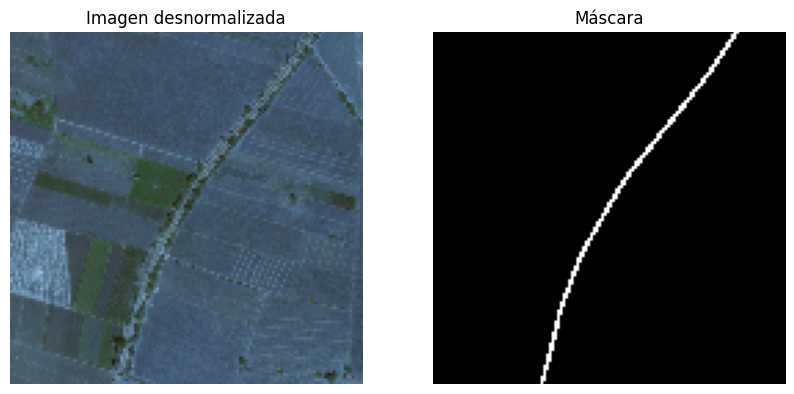

In [27]:
# Obtener un batch del train_loader
images, masks = next(iter(train_loader))

# Seleccionar la primera imagen y su máscara del batch
image = images[0]
mask = masks[0]

#Como en la transformación se le ha aplicado una normalización, para visualizarlo correctamente hay que desnormalizar
def denormalize(image_tensor, mean, std):
    """ Desnormaliza una imagen normalizada """
    image = image_tensor.clone()
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)
    return image

# Se aplica la desnormalización
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

denorm_img = denormalize(images[0], mean, std)
img_np = denorm_img.permute(1, 2, 0).cpu().numpy()

# Mostrar con matplotlib
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Imagen desnormalizada')
plt.imshow(np.clip(img_np, 0, 1))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Máscara')
plt.imshow(masks[0].squeeze().cpu(), cmap='gray')
plt.axis('off')

plt.show()


